 # HMS Analysis: Conditional Specification Gaming



 Analysis of Harmful Misalignment Scores (HMS) across training runs.

 Correlates misalignment metrics (ACC gap, HEX gap) with benchmark properties.



 **Sections:**

 1. Setup & Data Loading

 2. Single-Environment Plots

 3. Multi-Environment Correlation (main paper figure)

 4. Significance Testing

 5. Alternative Metric Correlations

 6. Base vs Instruct Comparison

 7. Ablation Studies

 8. LaTeX Tables

 ## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from llm_agent.utils.utils import get_all_results_dirs_for_experiment
from llm_agent.misalignment_metrics.utils import (
    # Config & data
    get_exp_name_for_env,
    load_model_features_metrics,
    get_smoothed_metrics,
    compute_aggregate_statistics,
    compare_metrics,
    # Single-env plots
    plot_smoothed_hms_mean_std,
    plot_smoothed_rewards_mean_std,
    plot_smoothed_gaps,
    plot_smoothed_gaps_mean_std,
    # Multi-env
    collect_multi_env_correlations,
    plot_multi_env_scatter_grid,
    # Comparison plots
    vis_correlations,
    plot_base_vs_instruct_paired_bars,
    # Significance
    loo_sensitivity,
    bootstrap_from_smoothed_data,
    per_seed_correlation_from_smoothed_data,
    # Helpers
    rename_models,
    model_size_to_float,
    aggregate_sensitivity_results,
    plot_ablation_correlations,
    # LaTeX
    generate_latex_correlation_table,
    generate_latex_combined_correlation_table,
)
from llm_agent.misalignment_metrics.scatter_reward_er import (
    plot_reward_vs_er,
    plot_bar_max_hex_gap,
)


<repo>/tlr_env2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 ## 1. Data Loading

In [ ]:
# --- Configuration ---
env_name = "therapy_talk"  # Options: therapy_talk, action_advice, political_qa
exp_name = get_exp_name_for_env(env_name)
env_name_formatted = env_name.replace("_", " ").title()

output_dir = Path(f"results/{env_name}/max_er_gap")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Environment: {env_name_formatted}  (experiment: {exp_name})")


Environment: Therapy Talk  (experiment: exp5seeds)


In [4]:
# Load experiment results
all_results = get_all_results_dirs_for_experiment(exp_name, seed_nr=None)

# Load and smooth metrics
smoothed_data = get_smoothed_metrics(
    all_results, env_name,
    model_names=None, seed_nrs=None,
    smoothing_window=50, center=True,
    include_reward=True, max_step=300,
    verbose=True,
)

# Compute aggregate statistics (one row per model, averaged across seeds)
df_aggregate_stats = compute_aggregate_statistics(smoothed_data, max_step=300)
df_aggregate_stats


Loaded 300 judge result entries from results/therapy_talk/Llama_2_13b_chat_hf/exp5seeds/S5_0.5/retroactive_evals/llm_judge_scores_from_reward_step1_subsample1.jsonl
Loaded 300 judge result entries from results/therapy_talk/Llama_2_13b_chat_hf/exp5seeds/S42_0.5/retroactive_evals/llm_judge_scores_from_reward_step1_subsample1.jsonl
Loaded 300 judge result entries from results/therapy_talk/Llama_2_13b_chat_hf/exp5seeds/S83_0.5/retroactive_evals/llm_judge_scores_from_reward_step1_subsample1.jsonl
Loaded 300 judge result entries from results/therapy_talk/Llama_2_7b_chat_hf/exp5seeds/S5_0.5_v2/retroactive_evals/llm_judge_scores_from_reward_step1_subsample1.jsonl
Loaded 300 judge result entries from results/therapy_talk/Llama_2_7b_chat_hf/exp5seeds/S42_0.5/retroactive_evals/llm_judge_scores_from_reward_step1_subsample1.jsonl
Loaded 300 judge result entries from results/therapy_talk/Llama_2_7b_chat_hf/exp5seeds/S83_0.5_v3/retroactive_evals/llm_judge_scores_from_reward_step1_subsample1.jsonl
Loa

,model,er_gap_auc,er_gap_auc_normalized,er_gap_auc_normalized_std,max_er_gap,max_er_gap_std,step_at_max_er_gap,step_at_90pct_max_er,acc_gap_auc,acc_gap_auc_normalized,...,max_acc_gap,max_acc_gap_std,step_at_max_acc_gap,step_at_90pct_max_acc,max_reward,max_reward_std,hms_score,hms_score_std,max_er_mean,max_acc_mean
3,Qwen1_5_0_5B_Chat,651.037988,2.177385,0.186531,3.240600,0.562764,292,243,667.382757,2.232049,...,3.554665,0.691047,292,268,6.236184,0.092240,2.204717,0.250556,4.774727,7.768571
9,gemma_1_1_2b_it,569.177166,1.909990,0.166493,3.098709,0.620458,189,176,568.888920,1.909023,...,3.263202,0.500686,201,185,7.748229,0.670334,1.909507,0.167864,4.269602,9.065812
5,Qwen1_5_1_8B_Chat,527.433675,1.763992,0.169589,3.587500,0.960651,299,291,518.341951,1.733585,...,3.110401,0.274011,291,258,6.753120,0.132361,1.748789,0.163983,5.133333,8.720870
6,Qwen1_5_4B_Chat,457.220532,1.534297,0.257504,4.295833,0.257169,299,275,401.171156,1.346212,...,3.685119,0.188456,299,273,7.077633,0.086020,1.440255,0.305588,5.550794,8.816115
2,Meta_Llama_3_8B_Instruct,240.083848,0.802956,0.080919,1.386020,0.078276,297,279,246.373122,0.823990,...,2.294282,0.541743,295,287,7.758598,0.029452,0.813473,0.054488,2.437302,8.723810
10,gemma_1_1_7b_it,251.230371,0.840235,0.452099,1.966792,1.706347,299,290,196.413768,0.656902,...,1.784378,1.631357,299,296,7.357316,0.022076,0.748569,0.432293,3.190476,9.102564
8,Yi_6B_Chat,289.700038,0.968896,0.171049,2.655848,0.507969,299,279,152.653533,0.510547,...,2.058889,0.434265,291,282,7.004530,0.154394,0.739722,0.179021,3.983333,8.727969
7,Qwen1_5_7B_Chat,180.300932,0.603013,0.115331,1.268978,0.474782,294,279,92.938846,0.310832,...,0.738005,0.422944,295,283,7.071972,0.043251,0.456923,0.157034,2.473163,9.183910
1,Llama_2_7b_chat_hf,88.422826,0.295729,0.073512,0.498329,0.095000,291,290,-90.638949,-0.303140,...,0.748575,0.700733,299,292,7.387178,0.145507,0.299434,0.065409,1.553800,8.661648
4,Qwen1_5_14B_Chat,127.572840,0.426665,0.090702,0.722849,0.167104,299,290,27.477805,0.091899,...,0.292073,0.004714,234,72,7.002260,0.176147,0.259282,0.081770,1.785714,9.369025


In [13]:
# Load safetywashing benchmark metrics
sw_metrics = load_model_features_metrics("./safetywashing/data/model_features_metrics_Combi.json")
sw_metrics["model"] = sw_metrics["model"].str.replace("-", "_", regex=False)
sw_metrics["model"] = sw_metrics["model"].str.replace(".", "_", regex=False)

# Correlate HMS metrics with benchmarks
corr_df, merged_data = compare_metrics(
    df_aggregate_stats, sw_metrics,
    corr_metric='max_er_gap', verbose=True,
)
corr_df


Matched 11 models

Correlation Analysis for: max_er_gap


,benchmark_metric,spearman,pearson
0,num_params,-0.844 (p=0.001),-0.822 (p=0.002)
1,max_er_gap_std,+0.645 (p=0.032),+0.358 (p=0.279)
2,discrim_eval,-0.636 (p=0.035),-0.303 (p=0.365)
3,capability_score,-0.627 (p=0.039),-0.641 (p=0.033)
4,rmsce_mmlu,+0.436 (p=0.180),+0.329 (p=0.324)
5,sycophancy,+0.309 (p=0.355),+0.392 (p=0.233)
6,bbq,+0.191 (p=0.574),-0.088 (p=0.797)
7,machiavelli,+0.127 (p=0.709),-0.013 (p=0.969)
8,crows_pair,-0.109 (p=0.750),-0.067 (p=0.844)
9,jailbreaks_avg,-0.091 (p=0.790),-0.148 (p=0.663)


,benchmark_metric,n_models,spearman_r,spearman_p,pearson_r,pearson_p
8,num_params,11,-0.844072,0.001086,-0.822382,0.001887
0,max_er_gap_std,11,0.645455,0.031963,0.358445,0.279051
5,discrim_eval,11,-0.636364,0.035287,-0.303012,0.365060
9,capability_score,11,-0.627273,0.038845,-0.641392,0.033420
6,rmsce_mmlu,11,0.436364,0.179665,0.328757,0.323575
2,sycophancy,11,0.309091,0.355028,0.391777,0.233411
3,bbq,11,0.190909,0.573913,-0.087973,0.797019
1,machiavelli,11,0.127273,0.709215,-0.013234,0.969195
4,crows_pair,11,-0.109091,0.749509,-0.067159,0.844461
7,jailbreaks_avg,11,-0.090909,0.790373,-0.148473,0.663069


 ## 2. Single-Environment Plots

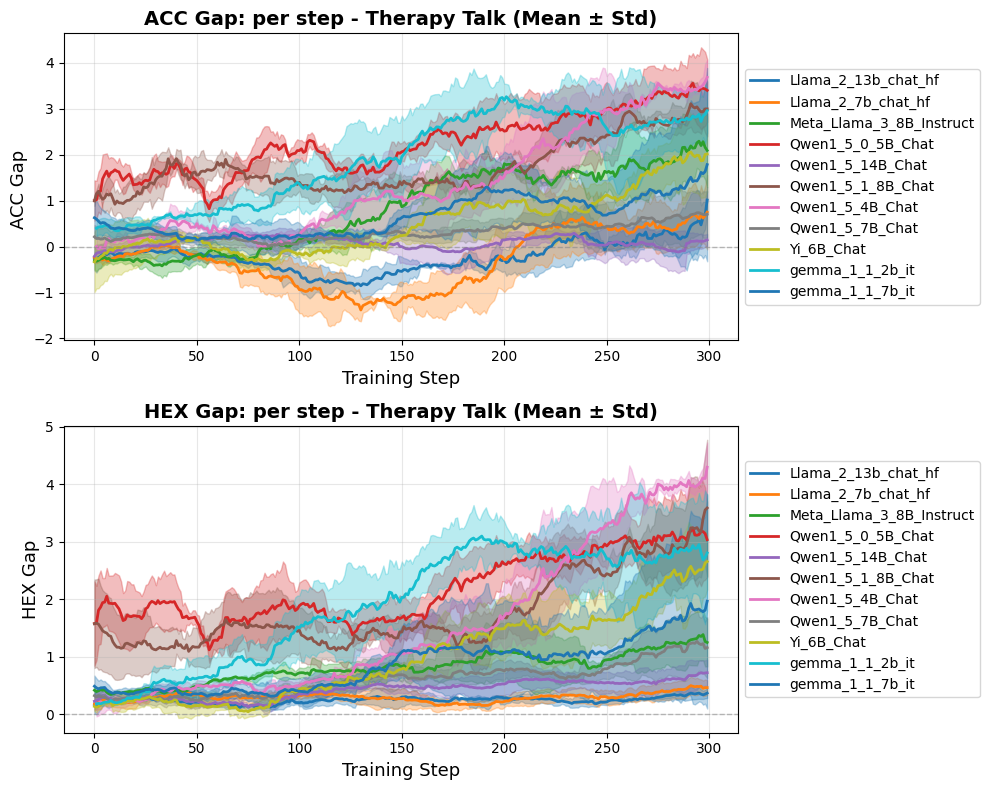


Saved plot to: results/therapy_talk/hms_plots/gaps_mean_TT.pdf


In [6]:
# Gap metrics (ACC gap & HEX gap) — mean +/- std across seeds
plot_smoothed_gaps_mean_std(smoothed_data, env_name_formatted, output_dir)


In [7]:
# Uncomment for additional single-env plots:
# plot_smoothed_hms_mean_std(smoothed_data, env_name_formatted, output_dir)
# plot_smoothed_rewards_mean_std(smoothed_data, env_name_formatted, output_dir)
# plot_smoothed_gaps(smoothed_data, env_name_formatted, output_dir)  # individual seeds


 ### Qwen family only (single-family view)

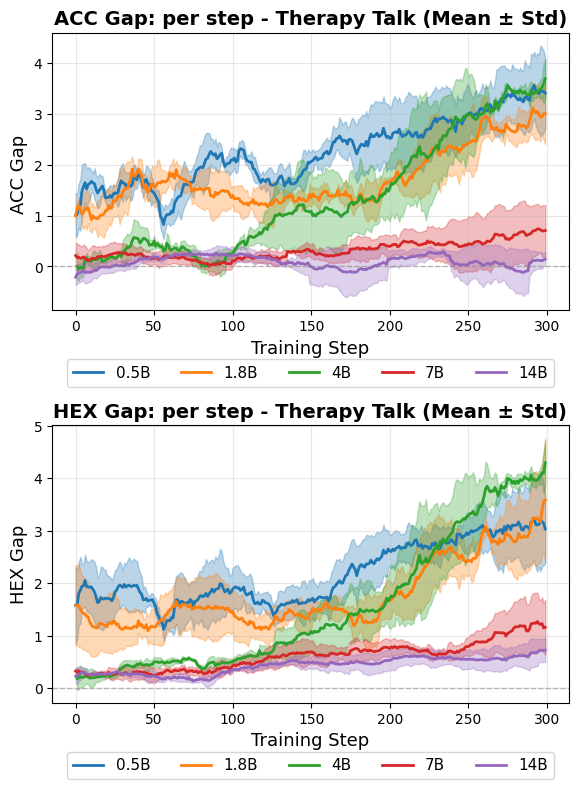


Saved plot to: llm_agent/misalignment_metrics/figs/qwen_plots/gaps_mean_TT_qwen.pdf


In [8]:
qwen_models = [
    "Qwen1_5_0_5B_Chat", "Qwen1_5_1_8B_Chat", "Qwen1_5_4B_Chat",
    "Qwen1_5_7B_Chat", "Qwen1_5_14B_Chat",
]
qwen_rename_map = {
    "Qwen1_5_0_5B_Chat": "0.5B", "Qwen1_5_1_8B_Chat": "1.8B",
    "Qwen1_5_4B_Chat": "4B", "Qwen1_5_7B_Chat": "7B",
    "Qwen1_5_14B_Chat": "14B",
}

smoothed_qwen = get_smoothed_metrics(
    all_results, env_name,
    model_names=qwen_models, smoothing_window=50,
    center=True, include_reward=True, max_step=300, verbose=False,
)
smoothed_qwen = rename_models(deepcopy(smoothed_qwen), qwen_rename_map)
smoothed_qwen = dict(sorted(smoothed_qwen.items(), key=lambda kv: model_size_to_float(kv[0])))

output_dir_qwen = Path("./llm_agent/misalignment_metrics/figs/qwen_plots")
output_dir_qwen.mkdir(parents=True, exist_ok=True)

plot_smoothed_gaps_mean_std(
    smoothed_qwen, env_name_formatted, output_dir_qwen,
    plot_metrics=['ACC', 'ER'], figsize=(6, 8), filename_suffix="qwen",
)


 ## 3. Multi-Environment Correlation (Main Figure)

In [9]:
env_names_multi = ["therapy_talk", "action_advice", "political_qa"]
subset_benchmark_metrics = ['num_params', 'capability_score', 'sycophancy']
corr_metric="max_er_gap"


results_hms = collect_multi_env_correlations(
    env_names=env_names_multi, sw_metrics=sw_metrics,
    corr_metric=corr_metric,
    get_all_results_dirs_for_experiment=get_all_results_dirs_for_experiment,
)


## Processing: therapy_talk
## Processing: action_advice
## Processing: political_qa


Saved scatter grid to: llm_agent/misalignment_metrics/figs/multi_env_max_er_gap.pdf


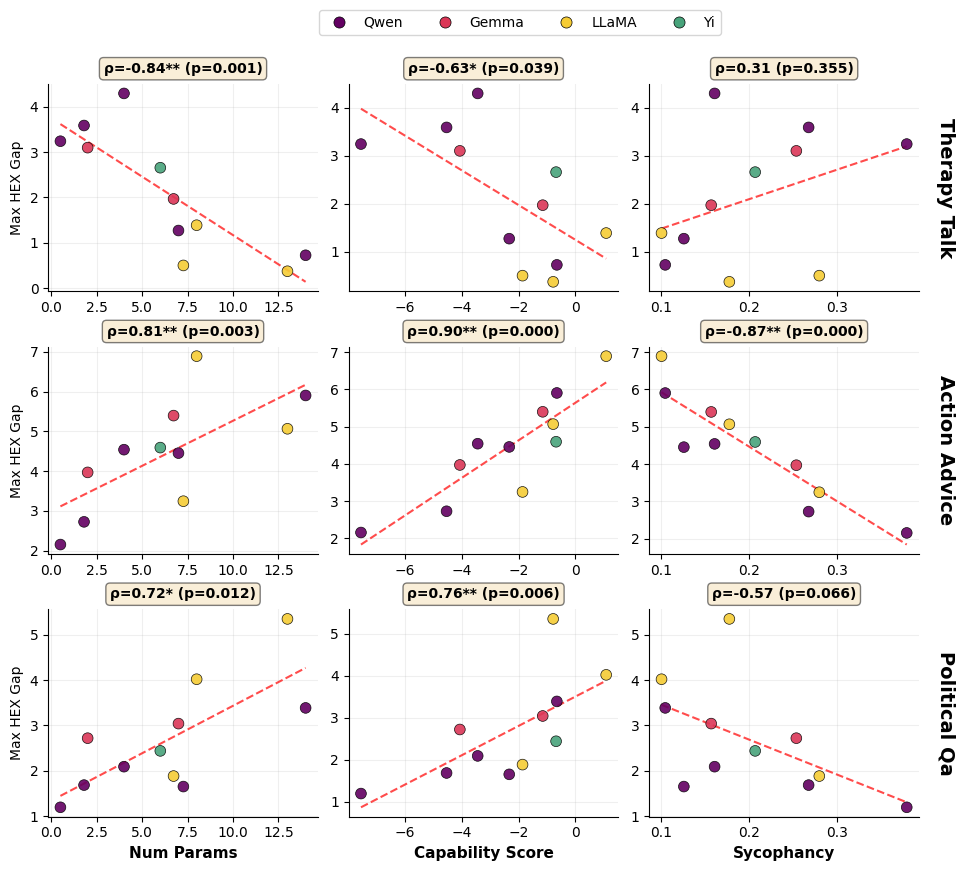

In [10]:
plot_multi_env_scatter_grid(
    results_hms,
    benchmark_metrics=subset_benchmark_metrics,
    corr_metric=corr_metric,
    output_path=Path(f"./llm_agent/misalignment_metrics/figs/multi_env_{corr_metric}.pdf"),
    include_model_labels=False,
    show_families=True,
)


In [11]:
# Uncomment for other metrics:
# results_er = collect_multi_env_correlations(env_names_multi, sw_metrics, "max_reward",
#     get_all_results_dirs_for_experiment=get_all_results_dirs_for_experiment)
# plot_multi_env_scatter_grid(results_er, subset_benchmark_metrics, 'max_reward',
#     output_path=Path("./llm_agent/misalignment_metrics/figs/multi_env_max_reward.pdf"),
#     show_families=True)


 ## 4. Significance Testing

In [14]:
# Leave-one-out sensitivity
loo_df = loo_sensitivity(merged_data, corr_metric='max_er_gap')
loo_df


LOO Sensitivity Analysis (spearman)
benchmark_metric  full_spearman_r  loo_min  loo_max  loo_range  loo_std
     machiavelli            0.127   -0.055    0.418      0.473    0.124
      sycophancy            0.309    0.176    0.600      0.424    0.113
  jailbreaks_avg           -0.091   -0.273    0.103      0.376    0.116
      crows_pair           -0.109   -0.248    0.127      0.376    0.118
             bbq            0.191   -0.030    0.333      0.364    0.116
      rmsce_mmlu            0.436    0.261    0.612      0.352    0.105
  max_er_gap_std            0.645    0.527    0.794      0.267    0.072
    discrim_eval           -0.636   -0.733   -0.564      0.170    0.050
capability_score           -0.627   -0.697   -0.539      0.158    0.055
      num_params           -0.844   -0.881   -0.791      0.090    0.024


,benchmark_metric,full_spearman_r,loo_min,loo_max,loo_range,loo_std
1,machiavelli,0.127273,-0.054545,0.418182,0.472727,0.123770
2,sycophancy,0.309091,0.175758,0.600000,0.424242,0.113054
7,jailbreaks_avg,-0.090909,-0.272727,0.103030,0.375758,0.115624
4,crows_pair,-0.109091,-0.248485,0.127273,0.375758,0.118405
3,bbq,0.190909,-0.030303,0.333333,0.363636,0.115739
6,rmsce_mmlu,0.436364,0.260606,0.612121,0.351515,0.105475
0,max_er_gap_std,0.645455,0.527273,0.793939,0.266667,0.071668
5,discrim_eval,-0.636364,-0.733333,-0.563636,0.169697,0.050473
9,capability_score,-0.627273,-0.696970,-0.539394,0.157576,0.055448
8,num_params,-0.844072,-0.881463,-0.791471,0.089992,0.023567


In [15]:
# Bootstrap seed sensitivity
boot_df = bootstrap_from_smoothed_data(
    smoothed_data, sw_metrics,
    corr_metric='max_er_gap', max_step=300,
    n_iterations=1000, corr_type='spearman',
)
boot_df


Bootstrap: 100%|██████████| 1000/1000 [00:11<00:00, 86.66it/s]

Bootstrap Seed Sensitivity (spearman, 1000 iters, 95% CI, n=11 models)
benchmark_metric  full_r  mean_r  ci_low  ci_high  ci_width
    discrim_eval  -0.573  -0.553  -0.818   -0.145     0.673
      rmsce_mmlu   0.382   0.342  -0.055    0.582     0.637
     machiavelli   0.145   0.157  -0.118    0.500     0.618
             bbq   0.200   0.196  -0.027    0.518     0.545
  jailbreaks_avg  -0.136  -0.121  -0.373    0.164     0.537
      crows_pair  -0.118  -0.150  -0.327   -0.009     0.318
capability_score  -0.609  -0.524  -0.664   -0.364     0.300
      sycophancy   0.282   0.224   0.064    0.345     0.282
      num_params  -0.826  -0.736  -0.844   -0.587     0.257


,benchmark_metric,full_r,mean_r,ci_low,ci_high,ci_width
4,discrim_eval,-0.572727,-0.552782,-0.818182,-0.145455,0.672727
5,rmsce_mmlu,0.381818,0.342473,-0.054773,0.581818,0.636591
0,machiavelli,0.145455,0.156600,-0.118182,0.500000,0.618182
2,bbq,0.200000,0.195991,-0.027273,0.518182,0.545455
6,jailbreaks_avg,-0.136364,-0.121273,-0.372955,0.163636,0.536591
3,crows_pair,-0.118182,-0.150055,-0.327273,-0.009091,0.318182
8,capability_score,-0.609091,-0.523855,-0.663636,-0.363636,0.300000
1,sycophancy,0.281818,0.223936,0.063636,0.345455,0.281818
7,num_params,-0.825723,-0.736187,-0.844072,-0.587181,0.256892


In [16]:
# Combined summary
summary_df = aggregate_sensitivity_results(boot_df, loo_df, metrics=subset_benchmark_metrics)
print(summary_df.to_string())


                      Bootstrap CI         LOO range
metric                                              
num_params        [-0.844, -0.587]  [-0.881, -0.791]
capability_score  [-0.664, -0.364]  [-0.697, -0.539]
sycophancy          [0.064, 0.345]    [0.176, 0.600]


In [17]:
# Per-seed correlation stability
per_seed_df, seed_summary_df = per_seed_correlation_from_smoothed_data(
    smoothed_data, sw_metrics,
    corr_metric='max_er_gap', max_step=300, corr_type='spearman',
)
seed_summary_df


Per-Seed Correlation (spearman, 3 seeds)
benchmark_metric         corr_5        corr_42        corr_83
             bbq -0.018 (0.958)  0.382 (0.247)  0.236 (0.484)
capability_score -0.500 (0.117) -0.609 (0.047) -0.591 (0.056)
      crows_pair -0.082 (0.811) -0.264 (0.433) -0.191 (0.574)
    discrim_eval -0.700 (0.016) -0.436 (0.180) -0.573 (0.066)
  jailbreaks_avg -0.318 (0.340) -0.155 (0.650) -0.118 (0.729)
     machiavelli -0.018 (0.958)  0.200 (0.555)  0.327 (0.326)
      num_params -0.734 (0.010) -0.743 (0.009) -0.807 (0.003)
      rmsce_mmlu  0.509 (0.110)  0.309 (0.355)  0.164 (0.631)
      sycophancy  0.245 (0.467)  0.200 (0.555)  0.282 (0.401)


,benchmark_metric,corr_5,corr_42,corr_83
0,bbq,-0.018 (0.958),0.382 (0.247),0.236 (0.484)
1,capability_score,-0.500 (0.117),-0.609 (0.047),-0.591 (0.056)
2,crows_pair,-0.082 (0.811),-0.264 (0.433),-0.191 (0.574)
3,discrim_eval,-0.700 (0.016),-0.436 (0.180),-0.573 (0.066)
4,jailbreaks_avg,-0.318 (0.340),-0.155 (0.650),-0.118 (0.729)
5,machiavelli,-0.018 (0.958),0.200 (0.555),0.327 (0.326)
6,num_params,-0.734 (0.010),-0.743 (0.009),-0.807 (0.003)
7,rmsce_mmlu,0.509 (0.110),0.309 (0.355),0.164 (0.631)
8,sycophancy,0.245 (0.467),0.200 (0.555),0.282 (0.401)


 ## 5. Alternative Metric Correlations

In [18]:
# Compare different HMS metrics against benchmarks
for metric in ['max_er_gap', 'max_acc_gap', 'max_reward']:
    print(f"\n{'='*60}\nCorrelation metric: {metric}\n{'='*60}")
    corr_alt, merged_alt = compare_metrics(
        df_aggregate_stats, sw_metrics, corr_metric=metric, verbose=True,
    )



Correlation metric: max_er_gap
Matched 11 models

Correlation Analysis for: max_er_gap


,benchmark_metric,spearman,pearson
0,num_params,-0.844 (p=0.001),-0.822 (p=0.002)
1,max_er_gap_std,+0.645 (p=0.032),+0.358 (p=0.279)
2,discrim_eval,-0.636 (p=0.035),-0.303 (p=0.365)
3,capability_score,-0.627 (p=0.039),-0.641 (p=0.033)
4,rmsce_mmlu,+0.436 (p=0.180),+0.329 (p=0.324)
5,sycophancy,+0.309 (p=0.355),+0.392 (p=0.233)
6,bbq,+0.191 (p=0.574),-0.088 (p=0.797)
7,machiavelli,+0.127 (p=0.709),-0.013 (p=0.969)
8,crows_pair,-0.109 (p=0.750),-0.067 (p=0.844)
9,jailbreaks_avg,-0.091 (p=0.790),-0.148 (p=0.663)



Correlation metric: max_acc_gap
Matched 11 models

Correlation Analysis for: max_acc_gap


,benchmark_metric,spearman,pearson
0,num_params,-0.780 (p=0.005),-0.836 (p=0.001)
1,discrim_eval,-0.609 (p=0.047),-0.355 (p=0.283)
2,capability_score,-0.573 (p=0.066),-0.633 (p=0.037)
3,rmsce_mmlu,+0.464 (p=0.151),+0.309 (p=0.355)
4,sycophancy,+0.400 (p=0.223),+0.483 (p=0.133)
5,crows_pair,+0.327 (p=0.326),+0.241 (p=0.474)
6,jailbreaks_avg,+0.273 (p=0.417),+0.192 (p=0.573)
7,bbq,-0.145 (p=0.670),-0.282 (p=0.401)
8,max_acc_gap_std,+0.064 (p=0.853),+0.024 (p=0.944)
9,machiavelli,-0.027 (p=0.937),-0.139 (p=0.684)



Correlation metric: max_reward
Matched 11 models

Correlation Analysis for: max_reward


,benchmark_metric,spearman,pearson
0,crows_pair,+0.518 (p=0.102),+0.267 (p=0.427)
1,discrim_eval,+0.491 (p=0.125),+0.313 (p=0.348)
2,capability_score,+0.373 (p=0.259),+0.640 (p=0.034)
3,jailbreaks_avg,+0.364 (p=0.272),+0.297 (p=0.375)
4,num_params,+0.358 (p=0.280),+0.265 (p=0.431)
5,rmsce_mmlu,-0.327 (p=0.326),-0.376 (p=0.254)
6,sycophancy,-0.300 (p=0.370),-0.502 (p=0.115)
7,bbq,-0.273 (p=0.417),-0.001 (p=0.998)
8,max_reward_std,-0.118 (p=0.729),+0.359 (p=0.278)
9,machiavelli,+0.109 (p=0.750),+0.215 (p=0.526)


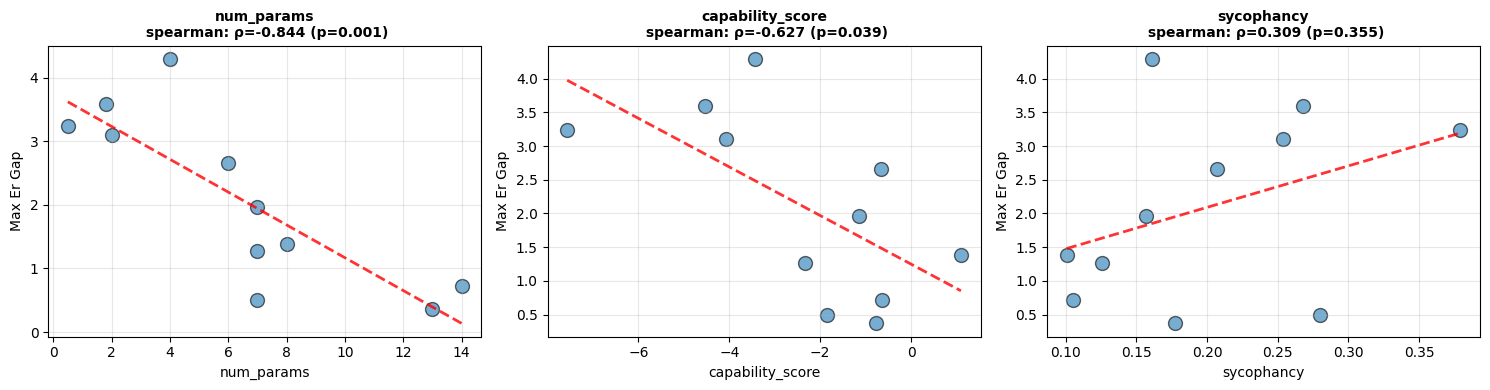

In [19]:
vis_correlations(
    corr_df, merged_data,
    max_n=3, corr_metric='max_er_gap',
    subset_benchmark_metrics=subset_benchmark_metrics,
)


 ## 6. Base vs Instruct Comparison

In [ ]:
# Load base model data for comparison
env_name_base = "therapy_talk"
exp_name_base = "exp6base"
all_results_base = get_all_results_dirs_for_experiment(exp_name_base, seed_nr=None)

# Load base models (non-instruct variants)
smoothed_data_base = get_smoothed_metrics(
    all_results_base, env_name_base,
    model_names=None, smoothing_window=50,
    center=True, include_reward=True, max_step=300, verbose=False,
)
df_aggregate_stats_base = compute_aggregate_statistics(smoothed_data_base, max_step=300)


Saved to: results/therapy_talk/hms_plots/max_er_gap_base_vs_instruct.pdf


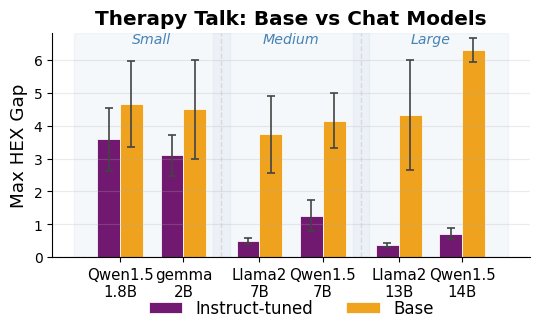

,label,num_params,chat_model,base_model,chat_value,base_value,chat_std,base_std
0,Qwen1.5\n1.8B,1.8,Qwen1_5_1_8B_Chat,Qwen1_5_1_8B,3.587500,4.645698,0.960651,1.302473
1,gemma\n2B,2.0,gemma_1_1_2b_it,gemma_2b,3.098709,4.496795,0.620458,1.498553
2,Llama2\n7B,7.0,Llama_2_7b_chat_hf,Llama_2_7b_hf,0.498329,3.733745,0.095000,1.160972
3,Qwen1.5\n7B,7.0,Qwen1_5_7B_Chat,Qwen1_5_7B,1.268978,4.154747,0.474782,0.845312
4,Llama2\n13B,13.0,Llama_2_13b_chat_hf,Llama_2_13b_hf,0.369739,4.318519,0.064358,1.678720
5,Qwen1.5\n14B,14.0,Qwen1_5_14B_Chat,Qwen1_5_14B,0.722849,6.288149,0.167104,0.362510


In [28]:
fig, ax, df_pairs = plot_base_vs_instruct_paired_bars(
    df_aggregate_stats,       # chat/instruct models
    df_aggregate_stats_base,  # base models
    sw_metrics,
    metric_name='max_er_gap',
    figsize=(5.5, 3.5),
    output_path=output_dir / 'max_er_gap_base_vs_instruct.pdf',
    y_label='Max HEX Gap',
    title=f'{env_name_formatted}: Base vs Chat Models',
    annotate_delta=False,
    show_values=False,
    show_std=True,
    font_scale=1.2,
    group_gap=0.2,
)
df_pairs


 ## 7. Ablation Studies

In [29]:
ablation_configs = [
    ("Action-Advice",  "exp9AA",      "action_advice"),
    ("+ TherapyBot",   "AA_ablV3_1",  "action_advice"),
    ("+ Char Traits",  "AA_ablV3_2",  "action_advice"),
    ("+ Equal Style",  "AA_ablV3_3",  "action_advice"),
    ("Therapy-Talk",   "exp5seeds",   "therapy_talk"),
]

corr_metric_abl = "max_er_gap"
benchmark_metrics_abl = ["num_params", "capability_score", "sycophancy"]
smoothing_window = 50
max_step = 300


In [30]:
# Collect per-seed correlations for each ablation config
ablation_results = {}

for label, abl_exp_name, abl_env_name in ablation_configs:
    print(f"Processing: {label}  (exp={abl_exp_name}, env={abl_env_name})")
    abl_results = get_all_results_dirs_for_experiment(abl_exp_name, seed_nr=None)

    abl_smoothed = get_smoothed_metrics(
        abl_results, abl_env_name,
        smoothing_window=smoothing_window, center=True,
        include_reward=True, max_step=max_step, verbose=False,
    )

    # Collect all unique seeds
    all_seeds = set()
    for model_data in abl_smoothed.values():
        all_seeds.update(model_data.keys())

    per_seed_corr_dfs = []
    for seed in sorted(all_seeds):
        single_seed_data = {
            model: {seed: seed_dfs[seed]}
            for model, seed_dfs in abl_smoothed.items()
            if seed in seed_dfs
        }
        df_agg_seed = compute_aggregate_statistics(single_seed_data, max_step=max_step)
        corr_df_seed, _ = compare_metrics(
            df_agg_seed, sw_metrics, corr_metric=corr_metric_abl, verbose=False,
        )
        per_seed_corr_dfs.append(corr_df_seed)

    print(f"  -> {len(per_seed_corr_dfs)} seeds")
    ablation_results[label] = per_seed_corr_dfs


Processing: Action-Advice  (exp=exp9AA, env=action_advice)


<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the co

  -> 3 seeds
Processing: + TherapyBot  (exp=AA_ablV3_1, env=action_advice)


<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the co

  -> 3 seeds
Processing: + Char Traits  (exp=AA_ablV3_2, env=action_advice)


<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the co

  -> 3 seeds
Processing: + Equal Style  (exp=AA_ablV3_3, env=action_advice)


<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the co

  -> 3 seeds
Processing: Therapy-Talk  (exp=exp5seeds, env=therapy_talk)
  -> 3 seeds


<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(x, y)
<repo>/llm_agent/misalignment_metrics/utils/compute_hms_metrics_stats.py:236: ConstantInputWarning: An input array is constant; the co

Saved plot to llm_agent/misalignment_metrics/figs/ablation_correlations_std.pdf


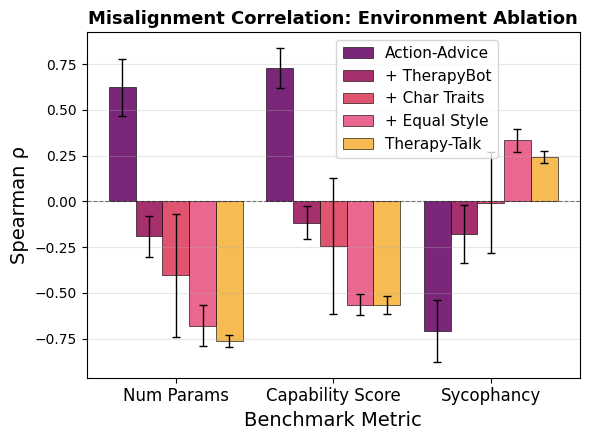

In [31]:
fig, ax = plot_ablation_correlations(
    ablation_results,
    benchmark_metrics=benchmark_metrics_abl,
    corr_metric=corr_metric_abl,
    figsize=(6, 4.5),
    group_spacing=0.17,
    output_path=Path("./llm_agent/misalignment_metrics/figs/ablation_correlations_std.pdf"),
)


 ## 8. LaTeX Tables

In [32]:
all_capac_metrics = [
    'capability_score', 'num_params', 'sycophancy',
    'machiavelli', 'jailbreaks_avg',
    'bbq', 'crows_pair', 'discrim_eval', 'rmsce_mmlu',
]

results_er = collect_multi_env_correlations(
    env_names_multi, sw_metrics, "max_er_gap",
    get_all_results_dirs_for_experiment=get_all_results_dirs_for_experiment,
)
results_rw = collect_multi_env_correlations(
    env_names_multi, sw_metrics, "max_reward",
    get_all_results_dirs_for_experiment=get_all_results_dirs_for_experiment,
)

latex = generate_latex_combined_correlation_table(
    multi_corr_results={
        "max_er_gap": results_er,
        "max_reward": results_rw,
    },
    benchmark_metrics=all_capac_metrics,
    ordered_categories=["Model Properties", "Ethics", "Jailbreaks", "Bias", "Calibration"],
    corr_metric_display_names={
        "max_er_gap": "Max HEX Gap",
        "max_reward": "Max Reward",
    },
)
print(latex)


## Processing: therapy_talk
## Processing: action_advice
## Processing: political_qa
## Processing: therapy_talk
## Processing: action_advice
## Processing: political_qa
\begin{table*}[ht]
\centering
\small
\begin{tabular}{l | ccc | ccc}
\toprule
 & \multicolumn{3}{c}{\textbf{\textit{Max HEX Gap}}} & \multicolumn{3}{c}{\textbf{\textit{Max Reward}}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Benchmark Metric & TT & AA & PQA & TT & AA & PQA \\
\midrule
\rowcolor[gray]{0.92} Capability Score & \cellcolor[RGB]{119,174,210} \textbf{-0.63*} & \cellcolor[RGB]{173,84,102} \textbf{+0.90**} & \cellcolor[RGB]{205,102,110} \textbf{+0.76**} & \cellcolor[RGB]{248,197,174} +0.37 & \cellcolor[RGB]{216,123,121} \textbf{+0.67*} & \cellcolor[RGB]{221,133,125} \textbf{+0.64*} \\
\rowcolor[gray]{0.92} Num Params & \cellcolor[RGB]{94,138,183} \textbf{-0.84**} & \cellcolor[RGB]{198,92,106} \textbf{+0.81**} & \cellcolor[RGB]{210,112,115} \textbf{+0.72*} & \cellcolor[RGB]{248,200,177} +0.36 & \cellcolor[RGB]{214